# Q12. Feature Selection using Statistical Understanding
**Context:** Not all features improve model performance.
**Dataset:** Iris

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset('iris')
print('Shape:', iris.shape)
iris.head()

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Task 1: Compute Correlation Matrix

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


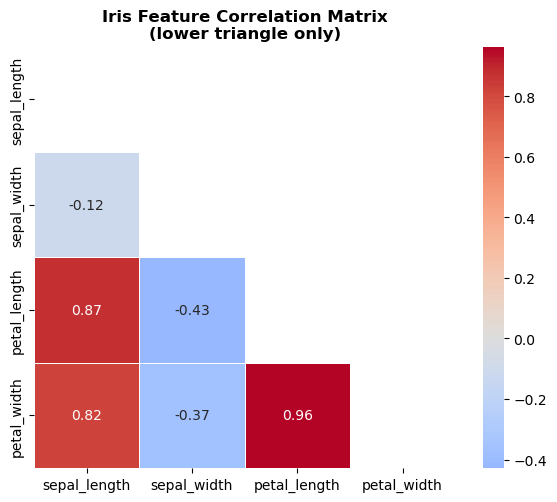

In [2]:
# Correlation on numeric features only
numeric_iris = iris.drop(columns='species')
corr_matrix = numeric_iris.corr()

print('Correlation Matrix:')
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, mask=mask,
            linewidths=0.5, ax=ax)
ax.set_title('Iris Feature Correlation Matrix\n(lower triangle only)', fontweight='bold')
plt.tight_layout()
plt.show()

## Task 2: Identify Highly Correlated Features

In [6]:
THRESHOLD = 0.85

# Extract upper triangle pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and abs(val) >= THRESHOLD:
            high_corr_pairs.append((row, col, round(val, 3)))

print(f'  Feature pairs with |correlation| >= {THRESHOLD}:')
print(f'  {"Feature A":<25} {"Feature B":<25} {"Correlation"}')

for f1, f2, r in high_corr_pairs:
    print(f'  {f1:<25} {f2:<25} {r}')

  Feature pairs with |correlation| >= 0.85:
  Feature A                 Feature B                 Correlation
  sepal_length              petal_length              0.872
  petal_length              petal_width               0.963


## Task 3: Drop Redundant Features

Original features  : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
After dropping     : ['sepal_length', 'sepal_width', 'petal_width']
Reduced from 4 → 3 features

Reduced Correlation Matrix:
              sepal_length  sepal_width  petal_width
sepal_length         1.000       -0.118        0.818
sepal_width         -0.118        1.000       -0.366
petal_width          0.818       -0.366        1.000


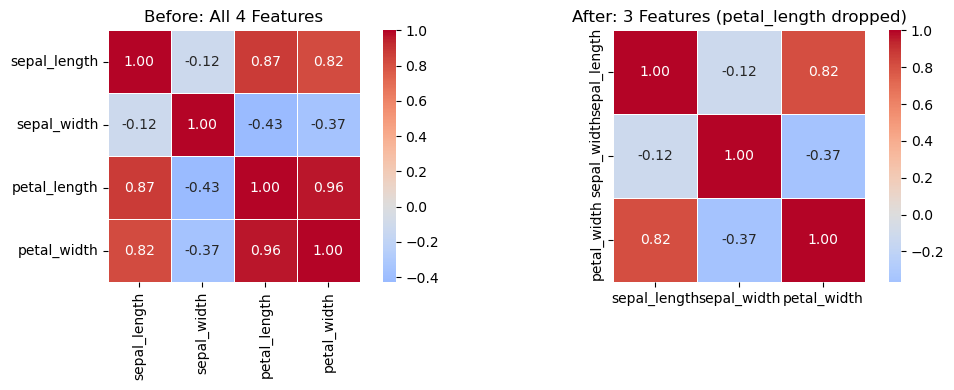

In [7]:
# petal_length and petal_width are highly correlated (r ≈ 0.96)
# sepal_length is also highly correlated with petal_length (r ≈ 0.87)
# Strategy: keep features that capture distinct variance
# Drop petal_length (redundant with petal_width AND sepal_length)

to_drop = ['petal_length']
iris_reduced = iris.drop(columns=to_drop)

print('Original features  :', list(iris.columns[:-1]))
print('After dropping     :', list(iris_reduced.columns[:-1]))
print(f'Reduced from {len(iris.columns)-1} → {len(iris_reduced.columns)-1} features')

# Verify reduced correlation matrix
new_corr = iris_reduced.drop(columns='species').corr()
print('\nReduced Correlation Matrix:')
print(new_corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0], linewidths=0.5)
axes[0].set_title('Before: All 4 Features')

sns.heatmap(new_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[1], linewidths=0.5)
axes[1].set_title('After: 3 Features (petal_length dropped)')

plt.tight_layout()
plt.show()